# 強化学習 実践入門

**多腕バンディットから Q-learning まで、実装して理解するハンズオン教材**

この Notebook では、強化学習（Reinforcement Learning; RL）の基本概念を、数式・実装・可視化を往復しながら学びます。外部の RL ライブラリは使わず、`NumPy` と `Matplotlib` だけでアルゴリズムの中身を実装します。

## 学習目標

学習後には、次のことができるようになります。

1. 状態・行動・報酬・方策・価値関数を説明できる
2. 探索と活用のトレードオフを実験で確認できる
3. ε-greedy 法と Q-learning をゼロから実装できる
4. 学習曲線と獲得方策を読み、ハイパーパラメータを調整できる

## 進め方

- 上から順にセルを実行してください。
- 実行時間の目安は 15〜30 分です。
- `TODO` の演習に取り組んでから、折りたたみ可能な解答例を確認してください。

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from matplotlib import font_manager

SEED = 42
np.set_printoptions(precision=3, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
import japanize_matplotlib
font_path = Path(japanize_matplotlib.__file__).parent / "fonts" / "ipaexg.ttf"
font_manager.fontManager.addfont(str(font_path))
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")

Python: 3.12.13
NumPy: 2.4.6


## 1. 強化学習の全体像

強化学習では、**エージェント**が**環境**と繰り返し相互作用します。

1. 環境から状態 $S_t$ を観測する
2. 方策 $\pi$ に従って行動 $A_t$ を選ぶ
3. 環境から報酬 $R_{t+1}$ と次状態 $S_{t+1}$ を受け取る
4. 将来を含む報酬の合計が大きくなるように学習する

割引収益（return）は次式です。

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots$$

$\gamma \in [0, 1]$ は割引率です。小さいほど目先の報酬を、大きいほど将来の報酬を重視します。

### 教師あり学習との違い

| 観点 | 教師あり学習 | 強化学習 |
|---|---|---|
| 教師信号 | 正解ラベル | 報酬 |
| データ | 固定データセットが中心 | 行動によってデータが変化 |
| 目的 | 予測誤差の最小化 | 長期的な累積報酬の最大化 |
| 難しさ | 汎化 | 探索、遅延報酬、信用割当 |

### ウォームアップ：割引収益を計算する

報酬列 $[1, 0, 2, 3]$ の各時点から見た割引収益を、後ろから再帰的に計算します。

$$G_t = R_{t+1} + \gamma G_{t+1}$$

In [2]:
def discounted_returns(rewards, gamma=0.9):
    """各時点からの割引収益を返す。"""
    returns = np.zeros(len(rewards), dtype=float)
    running_return = 0.0
    for t in reversed(range(len(rewards))):
        running_return = rewards[t] + gamma * running_return
        returns[t] = running_return
    return returns

rewards = [1, 0, 2, 3]
for gamma in [0.0, 0.5, 0.9, 1.0]:
    print(f"gamma={gamma:.1f}: {discounted_returns(rewards, gamma)}")

gamma=0.0: [1. 0. 2. 3.]
gamma=0.5: [1.875 1.75  3.5   3.   ]
gamma=0.9: [4.807 4.23  4.7   3.   ]
gamma=1.0: [6. 5. 5. 3.]


## 2. 多腕バンディット：探索と活用

多腕バンディットは「状態遷移のない」最小の強化学習問題です。スロットマシンに複数のレバーがあり、どのレバーが平均的に一番よい報酬を出すかを、実際に引きながら学ぶ状況だと考えると分かりやすいです。

この章では、各腕（行動） $a$ に未知の真の平均報酬 $q_*(a)$ があると仮定します。エージェントは $q_*(a)$ を直接見ることはできず、実際に腕を引いて得た報酬から推定値 $Q(a)$ を更新します。目的は、限られた試行回数の中で累積報酬を大きくすることです。

- **活用（exploitation）**：現在もっとも良いと推定した腕を選ぶ
- **探索（exploration）**：情報を得るため、別の腕も試す

ここでは ε-greedy 法を使います。確率 $1-\epsilon$ で最良の腕を、確率 $\epsilon$ でランダムな腕を選びます。

重要なのは、最初から「本当に良い腕」が分かっているわけではない点です。たまたま序盤に悪い報酬が出た腕を早く見捨てすぎると、実は良い腕だった可能性を逃します。逆に探索しすぎると、すでに良いと分かっている腕を選ぶ機会が減ります。この探索と活用のバランスが、強化学習全体で繰り返し現れる中心的なテーマです。

実装では、`true_values` が学習者には見えない真の平均報酬、`q_values` がエージェントの推定値、`counts` が各腕を選んだ回数です。報酬にはノイズがあるため、同じ腕を引いても毎回同じ値は返りません。

In [3]:
@dataclass
class GaussianBandit:
    true_values: np.ndarray
    noise_std: float = 1.0

    def pull(self, action, rng):
        return rng.normal(self.true_values[action], self.noise_std)


def epsilon_greedy(q_values, epsilon, rng):
    """ε-greedy で行動を選ぶ。同率最大ならランダムに決める。"""
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))
    best_actions = np.flatnonzero(q_values == q_values.max())
    return int(rng.choice(best_actions))


def run_bandit(true_values, epsilon=0.1, steps=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    env = GaussianBandit(np.asarray(true_values))
    q_values = np.zeros(len(true_values))
    counts = np.zeros(len(true_values), dtype=int)
    rewards = np.zeros(steps)
    optimal = np.zeros(steps)
    best_action = int(np.argmax(true_values))

    for t in range(steps):
        action = epsilon_greedy(q_values, epsilon, rng)
        reward = env.pull(action, rng)
        counts[action] += 1
        # 標本平均を逐次更新: Q <- Q + (R - Q) / N
        q_values[action] += (reward - q_values[action]) / counts[action]
        rewards[t] = reward
        optimal[t] = (action == best_action)

    return {"q_values": q_values, "counts": counts,
            "rewards": rewards, "optimal": optimal}


true_values = np.array([0.2, 1.0, 0.5, 1.5, -0.2])
result = run_bandit(true_values, epsilon=0.1)
print("真の平均報酬 :", true_values)
print("推定した価値 :", result["q_values"])
print("各腕の選択回数:", result["counts"])

真の平均報酬 : [ 0.2  1.   0.5  1.5 -0.2]
推定した価値 : [ 0.208  1.153  0.271  1.472 -0.238]
各腕の選択回数: [ 17  18  22 927  16]


### ε の違いを比較する

1 回の実験には偶然性があります。そこで複数の乱数 seed で実験し、平均累積報酬と最適行動率を比較します。

見るべき指標は 2 つです。

- **平均累積報酬**：ここまでに得た報酬の合計。実務上はこの値を大きくしたい
- **最適行動率**：真に平均報酬が最大の腕を選べた割合。学習が進んでいるかを見る診断指標

`ε=0` は完全な活用です。最初の偶然で良く見えた腕を選び続けるため、初期推定を間違えると回復できません。`ε` を少し入れると、たまに別の腕を試すので、序盤の誤解を修正できます。一方で `ε` が大きすぎると、学習後もランダム行動が多く残るため、累積報酬が伸びにくくなります。

この実験では `runs=200` として複数回の平均を取っています。強化学習の結果は乱数に強く左右されるため、単一 seed のグラフだけで手法の良し悪しを判断しないことが大切です。

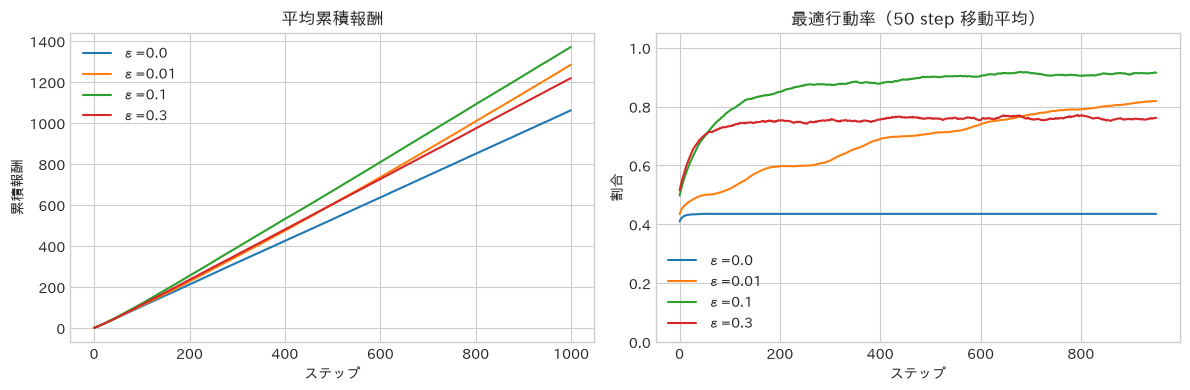

In [4]:
def compare_epsilons(true_values, epsilons, steps=1000, runs=200):
    summary = {}
    for epsilon in epsilons:
        rewards = []
        optimal = []
        for seed in range(runs):
            out = run_bandit(true_values, epsilon, steps, seed)
            rewards.append(out["rewards"])
            optimal.append(out["optimal"])
        summary[epsilon] = {
            "reward": np.mean(rewards, axis=0),
            "optimal": np.mean(optimal, axis=0),
        }
    return summary


epsilons = [0.0, 0.01, 0.1, 0.3]
bandit_summary = compare_epsilons(true_values, epsilons)

# このセルだけ再実行しても日本語ラベルが表示されるよう、フォントを明示します。
from pathlib import Path
from matplotlib import font_manager
import japanize_matplotlib
font_path = Path(japanize_matplotlib.__file__).parent / "fonts" / "ipaexg.ttf"
font_manager.fontManager.addfont(str(font_path))
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for epsilon, data in bandit_summary.items():
    axes[0].plot(np.cumsum(data["reward"]), label=f"ε={epsilon}")
    axes[1].plot(np.convolve(data["optimal"], np.ones(50) / 50, mode="valid"),
                 label=f"ε={epsilon}")
axes[0].set(title="平均累積報酬", xlabel="ステップ", ylabel="累積報酬")
axes[1].set(title="最適行動率（50 step 移動平均）", xlabel="ステップ", ylabel="割合", ylim=(0, 1.05))
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### 演習 1：非定常バンディット

現実では腕の価値が時間とともに変化することがあります。たとえば広告配信なら、ユーザーの興味や季節要因によって、同じ広告のクリック率が変わります。このような問題を**非定常**と呼びます。

上の実装で使った標本平均更新は、観測回数が $N$ のとき次の形でした。

$$Q(A_t) \leftarrow Q(A_t) + \frac{1}{N(A_t)} [R_t - Q(A_t)]$$

これは定常環境では自然な推定方法です。しかし $N$ が大きくなるほど新しい報酬の影響が小さくなるため、真の価値が変化したときに追従が遅くなります。

次の更新式を、固定ステップサイズ $\alpha=0.1$ に変更してください。

$$Q(A_t) \leftarrow Q(A_t) + \alpha [R_t - Q(A_t)]$$

考えてみよう：標本平均と固定 $\alpha$ のどちらが、最近の報酬を強く反映するでしょうか。

固定ステップサイズでは、常に一定割合だけ新しい観測を反映します。$\alpha$ が大きいほど変化に素早く反応しますが、報酬ノイズにも振り回されやすくなります。$\alpha$ が小さいほど推定は安定しますが、環境の変化には鈍くなります。

In [5]:
# TODO: 下の ??? を埋めてください（実行可能な初期値も入れてあります）
q_old, reward, alpha = 0.5, 1.2, 0.1
q_new = q_old + alpha * (reward - q_old)  # ???
print(f"更新前={q_old:.3f}, 更新後={q_new:.3f}")
assert np.isclose(q_new, 0.57), "更新式を確認しましょう"

更新前=0.500, 更新後=0.570


<details><summary>演習 1 の解答とポイント</summary>

```python
q_new = q_old + alpha * (reward - q_old)
```

固定ステップサイズでは直近の観測ほど大きな重みを持つため、非定常な環境に追従しやすくなります。一方、定常環境では標本平均が安定した推定値になります。
</details>

## 3. マルコフ決定過程（MDP）

状態遷移を含む強化学習問題は、一般に MDP として表現します。

- 状態集合 $\mathcal{S}$
- 行動集合 $\mathcal{A}$
- 遷移確率 $P(s'\mid s,a)$
- 報酬 $R(s,a,s')$
- 割引率 $\gamma$

行動価値関数 $Q^\pi(s,a)$ は「状態 $s$ で行動 $a$ を選び、その後は方策 $\pi$ に従ったときの期待収益」です。

Q-learning は、最適行動価値を次の TD（Temporal Difference）更新で学習します。

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1}+\gamma\max_a Q(S_{t+1},a)-Q(S_t,A_t)\right]$$

この式は、2章のバンディットで使った更新式と同じ形をしています。

$$\text{新しい推定値} \leftarrow \text{今の推定値} + \alpha(\text{目標値} - \text{今の推定値})$$

バンディットでは状態遷移がないため、目標値はその場で得た報酬 $R_t$ だけでした。MDP では、行動したあとに次状態 $S_{t+1}$ へ移動し、そこからさらに報酬を得られる可能性があります。そのため Q-learning では、目標値を次のように置きます。

$$\text{TD target}=R_{t+1}+\gamma\max_a Q(S_{t+1},a)$$

第1項の $R_{t+1}$ は、今回の行動で実際に得た即時報酬です。第2項の $\gamma\max_a Q(S_{t+1},a)$ は、次状態から先に期待できる将来価値です。$\max_a$ を取るのは「次状態では、現在の推定に基づいて最も価値が高い行動を選ぶならどれくらい得られそうか」を目標にするためです。

ただし、この TD target をそのまま $Q(S_t,A_t)$ に代入すると、1回の経験に強く振り回されます。そこで学習率 $\alpha$ を使い、今の推定値から目標値の方向へ少しだけ動かします。

$$\text{TD error}=\text{TD target}-Q(S_t,A_t)$$

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t)+\alpha\times\text{TD error}$$

つまり、括弧の中は「今の見積もりが、今回の経験から見てどれだけ外れていたか」を表します。TD 誤差が正なら $Q(S_t,A_t)$ は上がり、負なら下がります。終端状態ではその先の報酬がないため、将来価値は 0 とします。

#### 1ステップ先だけで十分なのか

上の式は $R_{t+1}$ だけを直接使うため、一見すると1ステップ先の報酬しか見ていないように見えます。しかし $Q(S_{t+1},a)$ 自体が「次状態から先に得られる将来報酬の合計」を推定しているため、学習が進むとさらに先の報酬も間接的に反映されます。このように、現在の推定値を使って別の推定値を更新する考え方を **bootstrapping** と呼びます。

一方で、数ステップ先までの実際の報酬を明示的に足してから更新する方法もあります。代表例が **n-step TD** です。

$$G_t^{(n)}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{n-1}R_{t+n}+\gamma^n\max_a Q(S_{t+n},a)$$

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t)+\alpha\left[G_t^{(n)}-Q(S_t,A_t)\right]$$

1-step Q-learning はすぐに更新できて安定しやすい一方、遠い報酬が手前の状態へ伝わるまでに時間がかかることがあります。n-step TD は数ステップ分の実報酬を直接使うため、遠い報酬を早く伝えられる場合がありますが、軌跡を保持する必要があり、報酬のばらつきにも影響されやすくなります。

## 4. GridWorld を作る

5×5 の盤面で、エージェントをスタート `S` からゴール `G` へ導きます。

- 行動：上・右・下・左
- 通常の移動：$-1$（短い経路を促す）
- 穴 `X`：$-10$ で終了
- ゴール `G`：$+10$ で終了
- 壁や盤外への移動：同じ場所に留まる

In [6]:
class GridWorld:
    ACTIONS = np.array([[-1, 0], [0, 1], [1, 0], [0, -1]])
    ACTION_NAMES = np.array(["↑", "→", "↓", "←"])

    def __init__(self, rows=5, cols=5):
        self.rows, self.cols = rows, cols
        self.start = (0, 0)
        self.goal = (4, 4)
        self.holes = {(1, 3), (3, 1)}
        self.walls = {(1, 1), (2, 1), (3, 3)}
        self.n_states = rows * cols
        self.n_actions = len(self.ACTIONS)
        self.state = self.start

    def state_to_id(self, state):
        return state[0] * self.cols + state[1]

    def id_to_state(self, state_id):
        return divmod(state_id, self.cols)

    def reset(self):
        self.state = self.start
        return self.state_to_id(self.state)

    def step(self, action):
        candidate = tuple(np.array(self.state) + self.ACTIONS[action])
        valid = (0 <= candidate[0] < self.rows and
                 0 <= candidate[1] < self.cols and
                 candidate not in self.walls)
        if valid:
            self.state = candidate

        terminated = self.state == self.goal or self.state in self.holes
        reward = 10.0 if self.state == self.goal else (-10.0 if self.state in self.holes else -1.0)
        return self.state_to_id(self.state), reward, terminated

    def render(self, path=None):
        path = set(path or [])
        for r in range(self.rows):
            row = []
            for c in range(self.cols):
                pos = (r, c)
                symbol = ("S" if pos == self.start else "G" if pos == self.goal else
                          "X" if pos in self.holes else "#" if pos in self.walls else
                          "·" if pos in path else ".")
                row.append(symbol)
            print(" ".join(row))


env = GridWorld()
env.render()

S . . . .
. # . X .
. # . . .
. X . # .
. . . . G


### ランダム方策を試す

学習前のエージェントがどの程度うまくいくか、基準値を確認します。安全のため 1 エピソードの最大ステップ数を設けます。

In [7]:
def run_random_policy(env, episodes=1000, max_steps=100, seed=SEED):
    rng = np.random.default_rng(seed)
    returns, successes = [], []
    for _ in range(episodes):
        env.reset()
        total_reward = 0.0
        success = False
        for _ in range(max_steps):
            action = int(rng.integers(env.n_actions))
            _, reward, terminated = env.step(action)
            total_reward += reward
            if terminated:
                success = env.state == env.goal
                break
        returns.append(total_reward)
        successes.append(success)
    return np.asarray(returns), np.asarray(successes)

random_returns, random_successes = run_random_policy(env)
print(f"ランダム方策の平均収益: {random_returns.mean():.2f}")
print(f"ランダム方策の成功率  : {random_successes.mean():.1%}")

ランダム方策の平均収益: -34.05
ランダム方策の成功率  : 5.0%


## 5. Q-learning を実装する

学習中は ε-greedy で探索し、評価時は最大の Q 値を持つ行動を選びます。ε はエピソードごとに減衰させ、序盤は広く探索、終盤は学んだ知識を活用します。

In [8]:
def train_q_learning(env, episodes=1000, alpha=0.1, gamma=0.95,
                     epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                     max_steps=100, seed=SEED):
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.n_states, env.n_actions))
    episode_returns = np.zeros(episodes)
    episode_lengths = np.zeros(episodes, dtype=int)
    epsilon_history = np.zeros(episodes)

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0.0
        epsilon_history[episode] = epsilon

        for step in range(max_steps):
            action = epsilon_greedy(q_table[state], epsilon, rng)
            next_state, reward, terminated = env.step(action)

            # 終端なら将来価値は 0
            next_value = 0.0 if terminated else np.max(q_table[next_state])
            td_target = reward + gamma * next_value
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward
            if terminated:
                break

        episode_returns[episode] = total_reward
        episode_lengths[episode] = step + 1
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    history = {"returns": episode_returns, "lengths": episode_lengths,
               "epsilons": epsilon_history}
    return q_table, history


q_table, history = train_q_learning(env)
print("Q-table shape:", q_table.shape)
print("開始状態の Q 値:", q_table[env.state_to_id(env.start)])

Q-table shape: (25, 4)
開始状態の Q 値: [-0.799  0.95  -3.403 -0.792]


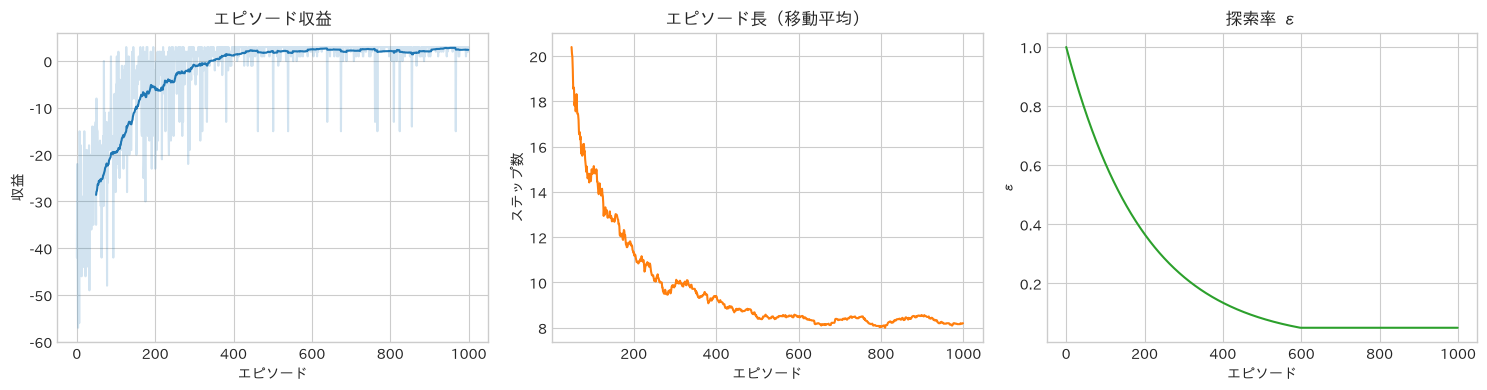

In [9]:
def moving_average(values, window=50):
    if len(values) < window:
        return np.asarray(values)
    return np.convolve(values, np.ones(window) / window, mode="valid")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["returns"], alpha=0.2, color="tab:blue")
axes[0].plot(np.arange(49, len(history["returns"])), moving_average(history["returns"]), color="tab:blue")
axes[0].set(title="エピソード収益", xlabel="エピソード", ylabel="収益")
axes[1].plot(np.arange(49, len(history["lengths"])), moving_average(history["lengths"]), color="tab:orange")
axes[1].set(title="エピソード長（移動平均）", xlabel="エピソード", ylabel="ステップ数")
axes[2].plot(history["epsilons"], color="tab:green")
axes[2].set(title="探索率 ε", xlabel="エピソード", ylabel="ε")
plt.tight_layout()
plt.show()

### 学習した方策を可視化する

各マスで最大の Q 値を持つ行動を矢印で表示します。未訪問状態では Q 値がすべて同じなので `?` と表示します。

In [10]:
def show_policy(env, q_table):
    for r in range(env.rows):
        row = []
        for c in range(env.cols):
            pos = (r, c)
            if pos == env.goal:
                symbol = "G"
            elif pos in env.holes:
                symbol = "X"
            elif pos in env.walls:
                symbol = "#"
            else:
                values = q_table[env.state_to_id(pos)]
                symbol = "?" if np.allclose(values, values[0]) else env.ACTION_NAMES[np.argmax(values)]
            row.append(symbol)
        print(" ".join(row))


show_policy(env, q_table)

→ → ↓ → ↓
↓ # ↓ X ↓
↓ # ↓ → ↓
↓ X ↓ # ↓
→ → → → G


In [11]:
def evaluate_greedy_policy(env, q_table, episodes=100, max_steps=100):
    returns, successes, final_path = [], [], []
    for _ in range(episodes):
        state = env.reset()
        path = [env.state]
        total_reward = 0.0
        for _ in range(max_steps):
            action = int(np.argmax(q_table[state]))
            state, reward, terminated = env.step(action)
            path.append(env.state)
            total_reward += reward
            if terminated:
                break
        returns.append(total_reward)
        successes.append(env.state == env.goal)
        final_path = path
    return np.asarray(returns), np.asarray(successes), final_path


eval_returns, eval_successes, learned_path = evaluate_greedy_policy(env, q_table)
print(f"学習済み方策の平均収益: {eval_returns.mean():.2f}")
print(f"学習済み方策の成功率  : {eval_successes.mean():.1%}")
print("\n獲得した経路（·）:")
env.render(learned_path)

assert eval_successes.mean() >= 0.95, "学習が不安定です。エピソード数や乱数 seed を見直してください。"

学習済み方策の平均収益: 3.00
学習済み方策の成功率  : 100.0%

獲得した経路（·）:
S · · . .
. # · X .
. # · . .
. X · # .
. . · · G


### 演習 2：TD 更新を手計算する

次の条件で更新後の $Q(s,a)$ を計算してください。

- 現在値：$Q(s,a)=2.0$
- 報酬：$r=1.0$
- 次状態の最大行動価値：$\max_{a'}Q(s',a')=4.0$
- 学習率：$\alpha=0.1$
- 割引率：$\gamma=0.9$

In [12]:
# TODO: 式を確認し、値を変更して実験してみましょう
q, reward, next_max_q, alpha, gamma = 2.0, 1.0, 4.0, 0.1, 0.9
td_target = reward + gamma * next_max_q
td_error = td_target - q
updated_q = q + alpha * td_error

print(f"TD target = {td_target:.2f}")
print(f"TD error  = {td_error:.2f}")
print(f"更新後 Q  = {updated_q:.2f}")
assert np.isclose(updated_q, 2.26)

TD target = 4.60
TD error  = 2.60
更新後 Q  = 2.26


<details><summary>演習 2 の解答</summary>

$$\text{TD target}=1.0+0.9\times4.0=4.6$$
$$\text{TD error}=4.6-2.0=2.6$$
$$Q_{new}=2.0+0.1\times2.6=2.26$$

正の TD 誤差なので、その行動の価値推定は上昇します。
</details>

### 演習 3：ハイパーパラメータ実験

学習率 $\alpha$ を変え、最後の 100 エピソードの平均収益を比較します。

観察のヒント：

- $\alpha$ が小さすぎると学習に時間がかかる
- $\alpha$ が大きすぎると推定値が振動しやすい
- 結果は環境・報酬の確率性・学習期間にも依存する

alpha=0.05: 最後の100話の平均収益 = 2.63
alpha= 0.1: 最後の100話の平均収益 = 2.59
alpha= 0.5: 最後の100話の平均収益 = 2.61


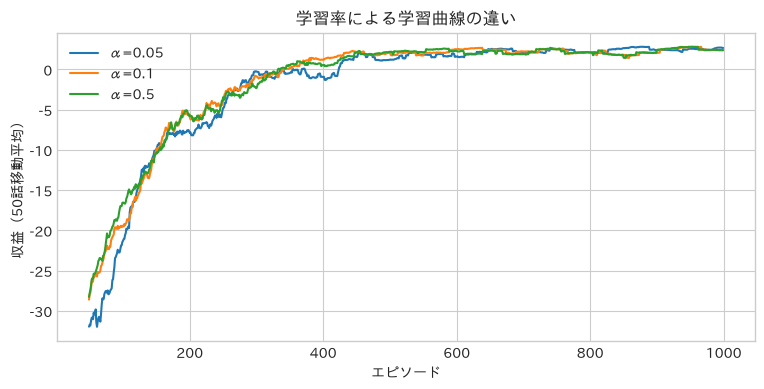

In [13]:
# TODO: 候補に 0.01 や 1.0 を追加して比較してみましょう
alphas = [0.05, 0.1, 0.5]
alpha_results = {}

for alpha_value in alphas:
    _, h = train_q_learning(GridWorld(), alpha=alpha_value, seed=SEED)
    alpha_results[alpha_value] = h["returns"]
    print(f"alpha={alpha_value:>4}: 最後の100話の平均収益 = {h['returns'][-100:].mean():.2f}")

plt.figure(figsize=(9, 4))
for alpha_value, returns in alpha_results.items():
    plt.plot(np.arange(49, len(returns)), moving_average(returns), label=f"α={alpha_value}")
plt.xlabel("エピソード")
plt.ylabel("収益（50話移動平均）")
plt.title("学習率による学習曲線の違い")
plt.legend()
plt.show()

## 6. 発展課題

理解を深めるには、次の順で改造してみてください。

1. **報酬設計**：通常報酬を `-0.1`、ゴールを `+1` に変え、方策が変わるか確認する
2. **確率的遷移**：10% の確率で意図と異なる方向へ動くよう `step` を変更する
3. **ε のスケジュール**：線形減衰や指数減衰を比較する
4. **SARSA**：次状態で実際に選んだ行動 $A_{t+1}$ を使う on-policy 更新を実装する
5. **Double Q-learning**：Q 値の過大評価を抑える方法を調べ、実装する

SARSA の更新式：

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha[R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)]$$

Q-learning は学習時の行動方策と評価対象の greedy 方策が異なる **off-policy**、SARSA は実際の行動を評価する **on-policy** です。下の実装では、次状態で実際に選んだ `next_action` の Q 値を使って更新します。

#### Q-learning と SARSA は何が違うのか

違いは、次状態 $S_{t+1}$ で「実際に選ぶ行動」と「更新式の中で評価する行動」が一致するかどうかです。

Q-learning の未来報酬項は次の形です。

$$\gamma\max_a Q(S_{t+1},a)$$

これは、次状態では常に greedy に最良行動を選ぶと仮定した値です。しかし学習中の行動選択は ε-greedy なので、実際には確率 $\epsilon$ で探索行動を選ぶことがあります。つまり Q-learning は、実際には探索で別の行動を取る可能性があっても、更新時には「次は最良行動を取った場合の価値」で学習します。

SARSA の未来報酬項は次の形です。

$$\gamma Q(S_{t+1},A_{t+1})$$

ここで $A_{t+1}$ は、次状態で ε-greedy によって実際に選ばれた行動です。探索によって悪い行動を選んだなら、その悪い行動の Q 値を使って更新します。そのため SARSA は「探索も含めた現在の行動方策」を評価します。

たとえば次状態での Q 値が `[10, 0, -5, 1]` だとします。greedy な行動は Q 値 10 の行動です。しかし ε-greedy の探索で、実際には Q 値 -5 の行動を選んだとします。このとき Q-learning は `10` を未来価値として使いますが、SARSA は実際に選んだ `-5` を使います。

したがって、$\epsilon=0$ で常に greedy に動くなら、両者の更新はほぼ同じになります。違いが出るのは、学習中に探索をしているときです。Q-learning は「探索しながらも、最終的に greedy に動く方策」を学び、SARSA は「探索を含めて実際に動いている方策」を学びます。

SARSA 方策の平均収益: 3.00
SARSA 方策の成功率  : 100.0%

SARSA で獲得した方策:
↓ → → → ↓
↓ # ↓ X ↓
↓ # → → ↓
↓ X ↓ # ↓
→ → → → G


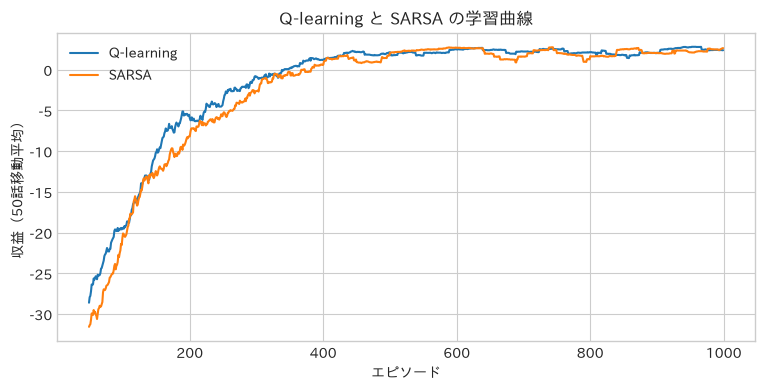

In [14]:
def train_sarsa(env, episodes=1000, alpha=0.1, gamma=0.95,
                epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                max_steps=100, seed=SEED):
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.n_states, env.n_actions))
    episode_returns = np.zeros(episodes)
    episode_lengths = np.zeros(episodes, dtype=int)
    epsilon_history = np.zeros(episodes)

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy(q_table[state], epsilon, rng)
        total_reward = 0.0
        epsilon_history[episode] = epsilon

        for step in range(max_steps):
            next_state, reward, terminated = env.step(action)
            total_reward += reward

            if terminated:
                td_target = reward
            else:
                next_action = epsilon_greedy(q_table[next_state], epsilon, rng)
                td_target = reward + gamma * q_table[next_state, next_action]

            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            if terminated:
                break

            state, action = next_state, next_action

        episode_returns[episode] = total_reward
        episode_lengths[episode] = step + 1
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    history = {"returns": episode_returns, "lengths": episode_lengths,
               "epsilons": epsilon_history}
    return q_table, history


sarsa_q_table, sarsa_history = train_sarsa(GridWorld())
sarsa_returns, sarsa_successes, sarsa_path = evaluate_greedy_policy(GridWorld(), sarsa_q_table)

print(f"SARSA 方策の平均収益: {sarsa_returns.mean():.2f}")
print(f"SARSA 方策の成功率  : {sarsa_successes.mean():.1%}")
print("\nSARSA で獲得した方策:")
show_policy(GridWorld(), sarsa_q_table)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(49, len(history["returns"])), moving_average(history["returns"]), label="Q-learning")
plt.plot(np.arange(49, len(sarsa_history["returns"])), moving_average(sarsa_history["returns"]), label="SARSA")
plt.xlabel("エピソード")
plt.ylabel("収益（50話移動平均）")
plt.title("Q-learning と SARSA の学習曲線")
plt.legend()
plt.show()

### 状態や行動が大きい場合

この Notebook の GridWorld では、状態数は `5×5=25`、行動数は `4` なので、`q_table` は `25×4` の小さな表で済みます。しかし状態数や行動数が大きい問題では、すべての状態・行動ペアに Q 値を持つ **tabular Q-learning** は現実的ではありません。

たとえばオセロでは、各マスが「空・黒・白」のいずれかを取り得るため、単純に数えると状態候補は $3^{64}$ 規模になります。実際に到達可能な局面はこれより少ないものの、それでも Q-table として全局面を列挙するには大きすぎます。行動は最大でも64マスへの着手ですが、合法手だけを選ぶ必要があるため、実装では **action mask** で非合法手を除外します。

このような場合は、Q 値を表で覚える代わりに、状態を入力すると価値や方策を出力する関数で近似します。代表的には次の方法があります。

- **特徴量 + 線形モデル**：盤面の特徴を手作りし、$Q(s,a)$ を線形関数で近似する
- **DQN**：ニューラルネットワークで $Q(s,a)$ を近似する。画像や盤面テンソルを入力にできる
- **Policy / Value network**：各行動の確率と局面価値を直接出す。AlphaZero 系のゲームAIで使われる
- **探索との併用**：MCTS などで先読みし、ネットワークは局面評価や着手候補の優先度に使う

要点は、「すべての状態を記憶する」のではなく、「似た状態に知識を汎化できる関数を学習する」ことです。小さな GridWorld では Q-table が理解しやすいですが、オセロのようなゲームではニューラルネットワークや探索を組み合わせる設計が一般的です。

### デモ：Q-table を使わない近似 Q-learning

次のデモでは、64個のビットを持つ盤面を考えます。各状態は長さ64の0/1ベクトルなので、状態候補は $2^{64}$ 通りあります。行動は「どのビットを反転するか」なので64通りです。

もし Q-table を作るなら $2^{64}\times64$ 個の値が必要ですが、これは現実的ではありません。そこで、状態・行動から特徴量 $\phi(s,a)$ を作り、次のような線形関数で Q 値を近似します。

$$Q(s,a)\approx w^\top\phi(s,a)$$

ここでは全行動で同じ重み `weights` を共有します。つまり、あるマスで学んだ「目標と違うビットを反転するとよい」という知識が、別のマスにもすぐ使われます。これが Q-table との大きな違いです。

このデモの特徴量は、`bitflip_features(state, target)` で作っています。戻り値は形状 `(64, 3)` の配列です。64行は64個の行動に対応し、各行が「その行動を今選ぶとどう見えるか」を表します。

| 特徴量 | 意味 | 直感 |
|---|---|---|
| `1` | バイアス項 | どの行動にも共通する基準値 |
| `mismatch[a]` | 行動 `a` のビットが目標と違うなら `1`、同じなら `0` | 目標と違うビットを反転すると近づく可能性が高い |
| `progress` | 盤面全体で、すでに目標と一致している割合 | 終盤か序盤かによって、同じ行動の価値が変わる可能性を持たせる |

たとえば、ある状態で `state[10] != target[10]` なら、行動10の特徴量はおおよそ `[1, 1, progress]` になります。一方、`state[20] == target[20]` なら、行動20の特徴量は `[1, 0, progress]` になります。学習が進むと、`mismatch` に対応する重みが正になり、「目標と違うビットを選ぶ行動」の Q 値が高くなります。

`target` は、この玩具環境でエージェントが一致させたい **目標ビット列** です。たとえば `target[10]=1` なのに `state[10]=0` なら、10番目のビットはまだ目標と違います。ここでの `target` は、Q-learning の更新式に出てくる `td_target` とは別物です。`target` は環境が持つゴール、`td_target` は1回の更新で現在の予測を近づけたい教師信号です。

このデモでは、更新する対象は Q-table のセルではなく `weights` です。`q_values_approx(state, target, weights)` は、今の `weights` を使って64個の行動それぞれの Q 値をその場で計算します。Q 値そのものを保存しているのではなく、Q 値を計算するためのパラメータを保存している、と考えると分かりやすいです。

更新は、通常の Q-learning と同じ TD 誤差から始まります。

$$\text{td\_target}=r+\gamma\max_{a'}Q(s',a')$$

$$\text{td\_error}=\text{td\_target}-Q(s,a)$$

tabular Q-learning では、選んだ状態・行動のセルだけを次のように更新しました。

$$Q(s,a)\leftarrow Q(s,a)+\alpha\times\text{td\_error}$$

一方、線形近似では $Q(s,a)=w^\top\phi(s,a)$ なので、Q 値を大きくしたければ、その行動の特徴量 $\phi(s,a)$ の方向へ `weights` を動かします。

$$w\leftarrow w+\alpha\times\text{td\_error}\times\phi(s,a)$$

コードでは、この式が次の1行に対応します。

```python
weights += alpha * td_error * features
```

`td_error` が正なら「実際には今の予測より良かった」という意味なので、その行動で立っていた特徴の重みを増やします。`td_error` が負なら「今の予測は高すぎた」という意味なので、その特徴の重みを下げます。たとえば `features=[1, 1, 0.5]` で `td_error` が正なら、`mismatch` に対応する重みも増えます。その結果、今後は「目標と違うビットを反転する行動」の Q 値が全体的に高くなります。

Q 値は次のように計算されます。

$$Q(s,a)=w_0\times1+w_1\times\text{mismatch}(s,a)+w_2\times\text{progress}(s)$$

重要なのは、ここでは `state` 全体をそのまま巨大なIDに変換していない点です。Q-table なら「この64ビット列そのもの」を1つの状態として別々に覚えますが、近似法では「この行動は目標と違うビットを反転するか」「盤面全体はどれくらい完成しているか」という小さな特徴に圧縮して学習します。そのため、過去にまったく同じ64ビット状態を見たことがなくても、特徴が似ていれば学習済みの重みを使って行動価値を推定できます。

この特徴量は人間が手で設計しています。オセロなら、たとえば次のような特徴が考えられます。

- その手は合法手か
- その手で何枚の石を裏返せるか
- 角を取る手か、角の隣に打つ危険な手か
- 自分の石数、相手の石数、空きマス数
- 着手後の合法手数、相手に与える合法手数

一方で、特徴抽出をニューラルネットワークに任せる方法もあります。DQN では、人間が `mismatch` や `progress` のような少数の特徴を手で作る代わりに、盤面テンソルをニューラルネットワークへ入力し、ネットワークの中間層が有用な特徴表現を学習します。つまり、線形近似では

$$Q(s,a)=w^\top\phi(s,a)$$

の $\phi(s,a)$ を人間が設計しますが、DQN では

$$Q(s,a)=f_\theta(s)_a$$

のように、ニューラルネットワーク $f_\theta$ が特徴抽出と Q 値計算をまとめて学習します。小さい教材では手作り特徴量の方が中身を追いやすく、大きなゲームや画像入力ではニューラルネットワークで特徴抽出を学習する方が一般的です。

Q-table に必要な要素数: 1.181e+21
float64 で保存した場合: 約 8192.0 EiB
学習した重み: [ 21.187   1.566 -16.523]
評価時の平均残りミスマッチ数: 0.00
評価時の成功率              : 100.0%


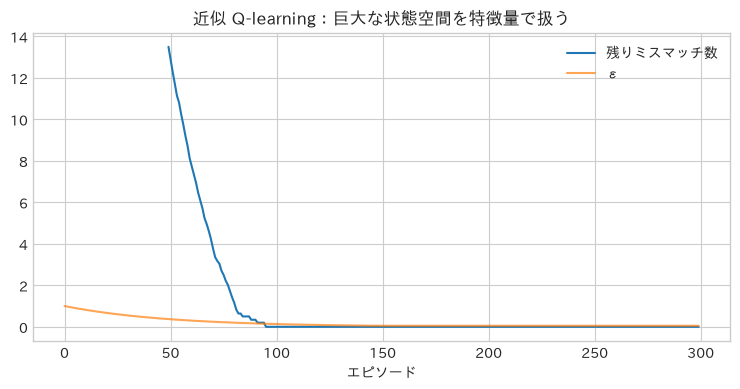

In [15]:
class BitFlip64Env:
    """64ビット盤面を目標パターンへ近づける玩具環境。"""

    def __init__(self, n_bits=64, max_steps=128, seed=SEED):
        self.n_bits = n_bits
        self.n_actions = n_bits
        self.max_steps = max_steps
        rng = np.random.default_rng(seed)
        # target は環境が持つ目標ビット列。td_target とは別の意味です。
        self.target = rng.integers(0, 2, size=n_bits, dtype=np.int8)
        self.rng = np.random.default_rng(seed + 1)
        self.state = None
        self.steps = 0

    def reset(self):
        self.state = self.rng.integers(0, 2, size=self.n_bits, dtype=np.int8)
        self.steps = 0
        return self.state.copy()

    def step(self, action):
        before = np.count_nonzero(self.state != self.target)
        self.state[action] = 1 - self.state[action]
        self.steps += 1
        after = np.count_nonzero(self.state != self.target)

        reward = float(before - after)  # 目標に近づけば +1、遠ざかれば -1
        terminated = after == 0 or self.steps >= self.max_steps
        return self.state.copy(), reward, terminated


def bitflip_features(state, target):
    """各行動 a に対する特徴量 phi(s, a) をまとめて返す。"""
    n = len(state)
    mismatch = (state != target).astype(float)
    progress = 1.0 - mismatch.mean()
    return np.column_stack([
        np.ones(n),              # バイアス項
        mismatch,                # その行動のビットが目標と違うか
        np.full(n, progress),    # 盤面全体がどれくらい完成に近いか
    ])


def q_values_approx(state, target, weights):
    return bitflip_features(state, target) @ weights


def train_approx_q_learning(env, episodes=300, alpha=0.05, gamma=0.95,
                            epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.98,
                            seed=SEED):
    rng = np.random.default_rng(seed)
    weights = np.zeros(3)
    episode_returns = np.zeros(episodes)
    final_distances = np.zeros(episodes)
    epsilon_history = np.zeros(episodes)

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0.0
        epsilon_history[episode] = epsilon

        for _ in range(env.max_steps):
            q_values = q_values_approx(state, env.target, weights)
            action = epsilon_greedy(q_values, epsilon, rng)
            features = bitflip_features(state, env.target)[action]

            next_state, reward, terminated = env.step(action)
            next_value = 0.0 if terminated else q_values_approx(next_state, env.target, weights).max()
            # td_target は「今回の経験から見た、近づけたい Q 値」です。
            td_target = reward + gamma * next_value
            td_error = td_target - q_values[action]

            # Q-table のセルではなく、Q 値を計算するための重みを更新します。
            weights += alpha * td_error * features
            state = next_state
            total_reward += reward
            if terminated:
                break

        episode_returns[episode] = total_reward
        final_distances[episode] = np.count_nonzero(state != env.target)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    history = {"returns": episode_returns, "distances": final_distances,
               "epsilons": epsilon_history}
    return weights, history


def evaluate_bitflip_policy(env, weights, episodes=100):
    distances, successes = [], []
    for _ in range(episodes):
        state = env.reset()
        for _ in range(env.max_steps):
            action = int(np.argmax(q_values_approx(state, env.target, weights)))
            state, _, terminated = env.step(action)
            if terminated:
                break
        distance = np.count_nonzero(state != env.target)
        distances.append(distance)
        successes.append(distance == 0)
    return np.asarray(distances), np.asarray(successes)


entries = (2 ** 64) * 64
memory_eib = entries * 8 / (1024 ** 6)
print(f"Q-table に必要な要素数: {entries:.3e}")
print(f"float64 で保存した場合: 約 {memory_eib:.1f} EiB")

bit_env = BitFlip64Env()
approx_weights, approx_history = train_approx_q_learning(bit_env)
bitflip_distances, bitflip_successes = evaluate_bitflip_policy(BitFlip64Env(), approx_weights)

print("学習した重み:", approx_weights)
print(f"評価時の平均残りミスマッチ数: {bitflip_distances.mean():.2f}")
print(f"評価時の成功率              : {bitflip_successes.mean():.1%}")

plt.figure(figsize=(9, 4))
plt.plot(np.arange(49, len(approx_history["distances"])),
         moving_average(approx_history["distances"]), label="残りミスマッチ数")
plt.plot(approx_history["epsilons"], label="ε", alpha=0.7)
plt.xlabel("エピソード")
plt.title("近似 Q-learning：巨大な状態空間を特徴量で扱う")
plt.legend()
plt.show()

### DQNのデモ

⚪︎×ゲームを題材にDQNのデモを作成する

ランダムな後手との500局: 勝ち 96.0% / 引分 0.0% / 負け 4.0%

勝った対局の最終盤面（○: DQN、×: ランダム）
・ ・ ○
・ ・ ○
× × ○


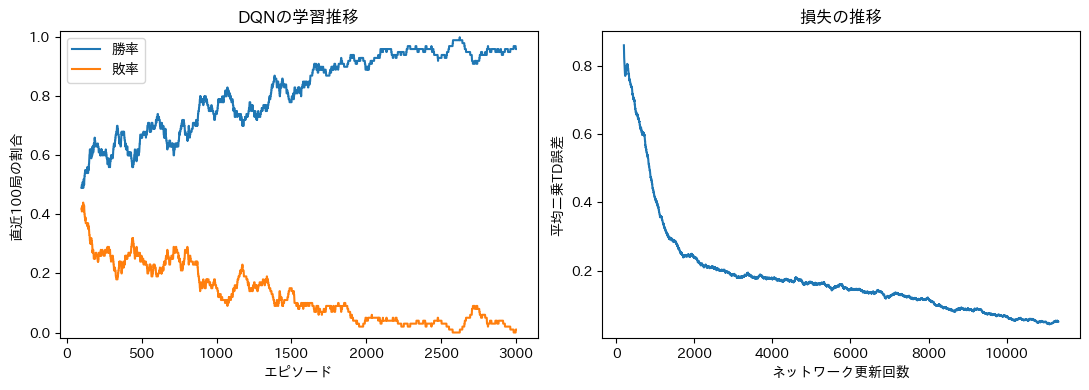

In [4]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

SEED = 0

class TicTacToeEnv:
    WIN_LINES = np.array([
        [0, 1, 2], [3, 4, 5], [6, 7, 8],
        [0, 3, 6], [1, 4, 7], [2, 5, 8],
        [0, 4, 8], [2, 4, 6],
    ])

    def __init__(self, seed=SEED):
        self.rng = np.random.default_rng(seed)
        self.board = np.zeros(9, dtype=np.float32)

    def reset(self):
        self.board.fill(0)
        return self.board.copy()

    def valid_actions(self):
        return np.flatnonzero(self.board == 0)

    def has_won(self, player):
        return np.any(
            np.all(self.board[self.WIN_LINES] == player, axis=1)
        )

    def step(self, action):
        if self.board[action] != 0:
            raise ValueError("すでに埋まっているマスです")

        # DQNエージェントは先手の○
        self.board[action] = 1

        if self.has_won(1):
            return self.board.copy(), 1.0, True

        if not self.valid_actions().size:
            return self.board.copy(), 0.2, True

        # 後手の×はランダムに行動
        opponent_action = int(self.rng.choice(self.valid_actions()))
        self.board[opponent_action] = -1

        if self.has_won(-1):
            return self.board.copy(), -1.0, True

        if not self.valid_actions().size:
            return self.board.copy(), 0.2, True

        return self.board.copy(), 0.0, False


class TinyQNetwork:
    """9入力、64ユニットの隠れ層、9出力のQネットワーク。"""

    def __init__(self, hidden_size=64, seed=SEED):
        rng = np.random.default_rng(seed)

        self.w1 = rng.normal(
            0,
            np.sqrt(2 / 9),
            size=(9, hidden_size),
        )
        self.b1 = np.zeros(hidden_size)

        self.w2 = rng.normal(
            0,
            np.sqrt(2 / hidden_size),
            size=(hidden_size, 9),
        )
        self.b2 = np.zeros(9)

    def predict(self, states):
        states = np.atleast_2d(states)
        hidden = np.maximum(0, states @ self.w1 + self.b1)
        return hidden @ self.w2 + self.b2

    def train_batch(self, states, actions, targets, learning_rate):
        hidden_pre = states @ self.w1 + self.b1
        hidden = np.maximum(0, hidden_pre)
        q_values = hidden @ self.w2 + self.b2

        errors = (
            q_values[np.arange(len(states)), actions] - targets
        )

        grad_q = np.zeros_like(q_values)
        grad_q[np.arange(len(states)), actions] = (
            2 * errors / len(states)
        )

        grad_w2 = hidden.T @ grad_q
        grad_b2 = grad_q.sum(axis=0)

        grad_hidden = (
            grad_q @ self.w2.T
        ) * (hidden_pre > 0)

        grad_w1 = states.T @ grad_hidden
        grad_b1 = grad_hidden.sum(axis=0)

        # 大きすぎる勾配を抑えて学習を安定させる
        self.w1 -= learning_rate * np.clip(grad_w1, -5, 5)
        self.b1 -= learning_rate * np.clip(grad_b1, -5, 5)
        self.w2 -= learning_rate * np.clip(grad_w2, -5, 5)
        self.b2 -= learning_rate * np.clip(grad_b2, -5, 5)

        return float(np.mean(errors ** 2))

    def copy_from(self, other):
        for name in ("w1", "b1", "w2", "b2"):
            setattr(self, name, getattr(other, name).copy())


def select_ttt_action(
    network,
    state,
    rng=None,
    epsilon=0.0,
):
    valid_actions = np.flatnonzero(state == 0)

    if rng is not None and rng.random() < epsilon:
        return int(rng.choice(valid_actions))

    q_values = network.predict(state)[0]

    # すでに埋まっているマスを選択候補から除外
    q_values[state != 0] = -np.inf

    best_actions = np.flatnonzero(
        q_values == q_values.max()
    )

    if rng is None:
        return int(best_actions[0])

    return int(rng.choice(best_actions))


def train_tictactoe_dqn(
    episodes=3000,
    batch_size=32,
    gamma=0.95,
    learning_rate=0.01,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    env = TicTacToeEnv(seed)

    online_network = TinyQNetwork(seed=seed)
    target_network = TinyQNetwork(seed=seed + 1)
    target_network.copy_from(online_network)

    replay_buffer = deque(maxlen=5000)

    outcomes = np.zeros(episodes)
    losses = []
    updates = 0

    for episode in range(episodes):
        state = env.reset()

        epsilon = max(
            0.05,
            1.0 - 0.95 * episode / (episodes * 0.75),
        )

        done = False

        while not done:
            action = select_ttt_action(
                online_network,
                state,
                rng,
                epsilon,
            )

            next_state, reward, done = env.step(action)

            replay_buffer.append(
                (state, action, reward, next_state, done)
            )

            state = next_state

            if len(replay_buffer) < batch_size:
                continue

            indices = rng.choice(
                len(replay_buffer),
                batch_size,
                replace=False,
            )
            batch = [replay_buffer[i] for i in indices]

            states = np.stack([item[0] for item in batch])
            actions = np.array([item[1] for item in batch])
            rewards = np.array([item[2] for item in batch])
            next_states = np.stack(
                [item[3] for item in batch]
            )
            dones = np.array(
                [item[4] for item in batch],
                dtype=bool,
            )

            next_values = np.zeros(batch_size)
            active = ~dones

            if active.any():
                next_q_values = target_network.predict(
                    next_states[active]
                )

                # 次状態でも埋まっているマスを除外
                next_q_values[
                    next_states[active] != 0
                ] = -np.inf

                next_values[active] = next_q_values.max(
                    axis=1
                )

            td_targets = rewards + gamma * next_values

            loss = online_network.train_batch(
                states,
                actions,
                td_targets,
                learning_rate,
            )
            losses.append(loss)

            updates += 1

            if updates % 100 == 0:
                target_network.copy_from(online_network)

        outcomes[episode] = reward

    return (
        online_network,
        outcomes,
        np.asarray(losses),
    )


def evaluate_tictactoe(
    network,
    games=500,
    seed=SEED + 100,
):
    env = TicTacToeEnv(seed)
    outcomes = []
    example_board = None

    for _ in range(games):
        state = env.reset()
        done = False

        while not done:
            action = select_ttt_action(network, state)
            state, reward, done = env.step(action)

        outcomes.append(reward)

        if example_board is None and reward == 1.0:
            example_board = state.copy()

    return np.asarray(outcomes), example_board


def format_board(board):
    symbols = {
        1.0: "○",
        -1.0: "×",
        0.0: "・",
    }

    return "\n".join(
        " ".join(
            symbols[float(value)]
            for value in row
        )
        for row in board.reshape(3, 3)
    )


dqn, dqn_outcomes, dqn_losses = (
    train_tictactoe_dqn()
)

evaluation, example_board = evaluate_tictactoe(dqn)

win_rate = np.mean(evaluation == 1.0)
draw_rate = np.mean(evaluation == 0.2)
loss_rate = np.mean(evaluation == -1.0)

print(
    "ランダムな後手との500局: "
    f"勝ち {win_rate:.1%} / "
    f"引分 {draw_rate:.1%} / "
    f"負け {loss_rate:.1%}"
)

if example_board is not None:
    print(
        "\n勝った対局の最終盤面"
        "（○: DQN、×: ランダム）"
    )
    print(format_board(example_board))


window = 100
x = np.arange(window - 1, len(dqn_outcomes))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)

for outcome, label in [
    (1.0, "勝率"),
    (-1.0, "敗率"),
]:
    values = (
        dqn_outcomes == outcome
    ).astype(float)

    moving_rate = np.convolve(
        values,
        np.ones(window) / window,
        mode="valid",
    )

    axes[0].plot(
        x,
        moving_rate,
        label=label,
    )

axes[0].set(
    xlabel="エピソード",
    ylabel="直近100局の割合",
    title="DQNの学習推移",
    ylim=(-0.02, 1.02),
)
axes[0].legend()

loss_window = 200
loss_x = np.arange(
    loss_window - 1,
    len(dqn_losses),
)
moving_loss = np.convolve(
    dqn_losses,
    np.ones(loss_window) / loss_window,
    mode="valid",
)

axes[1].plot(loss_x, moving_loss)
axes[1].set(
    xlabel="ネットワーク更新回数",
    ylabel="平均二乗TD誤差",
    title="損失の推移",
)

plt.tight_layout()
plt.show()

## 7. 実務でのチェックリスト

- **MDP として妥当か**：状態に意思決定に必要な情報が含まれるか
- **報酬ハッキングはないか**：代理指標だけを攻略する抜け道がないか
- **ベースラインはあるか**：ランダム方策・ルールベース手法と比較したか
- **複数 seed で評価したか**：平均だけでなく分散や信頼区間も見たか
- **学習と評価を分離したか**：評価時には探索を切ったか
- **安全制約があるか**：実環境で危険な探索を許していないか
- **オフライン評価を検討したか**：シミュレータや過去ログを活用できないか

強化学習は「予測」ではなく「介入」を学びます。そのため、オンライン広告・推薦・ロボットなどでは、性能だけでなく安全性、公平性、説明可能性、実験コストも重要です。

## 8. まとめ

- 強化学習は、環境との相互作用から累積報酬を最大化する方策を学ぶ
- ε-greedy は探索と活用を単純かつ有効に両立する
- Q-learning は TD 誤差を使って、モデルなしで最適行動価値を学ぶ
- 学習曲線、複数 seed、ベースラインによる評価が重要
- 実務では報酬設計と安全な探索が成否を左右する

次の一歩として、Gymnasium の `FrozenLake` や `CartPole` を試し、状態が大きい場合に Q-table をニューラルネットワークへ置き換える DQN へ進むと理解がつながります。

## 理解度チェック

1. ε を 0 にすると、どのような問題が起こり得ますか？
2. 終端状態の次状態価値を 0 とするのはなぜですか？
3. 学習率 $\alpha$ と割引率 $\gamma$ は、それぞれ何を制御しますか？
4. Q-learning が off-policy と呼ばれる理由を説明してください。
5. 学習済み方策を 1 回だけでなく複数回評価すべき理由は何ですか？

<details><summary>解答例</summary>

1. 初期に得た不正確な推定へ固定され、より良い行動を発見できない可能性があります。
2. エピソード終了後には将来の報酬が存在しないためです。
3. $\alpha$ は新しい情報をどれだけ強く反映するか、$\gamma$ は将来報酬をどれだけ重視するかを制御します。
4. 行動は ε-greedy で選びながら、更新対象には greedy な最大 Q 値を使うためです。
5. 環境や方策に確率性がある場合、1 回の結果は偶然に左右されるためです。
</details>